# Versao 11 - Classificacao Multiclasse Com LSTM Multitarefa

Este notebook treina exatamente a mesma arquitetura central da `versao10`. A diferenca experimental esta no que chega a ela depois do novo pre-processamento da `versao11`.

    ## Resultados Da Ultima Execucao Registrada

    Os artefatos atuais da `versao11` mostram:

    - melhor checkpoint na epoca `19`
    - validacao: `accuracy = 0.8851`, `macro-F1 = 0.8724`, `balanced accuracy = 0.8921`
    - teste: `accuracy = 0.9213`, `macro-F1 = 0.9155`, `balanced accuracy = 0.9225`
- variacao sobre a `versao10`: `-0.0160` em `accuracy`, `-0.0253` em `macro-F1` e `-0.0347` em `balanced accuracy`
    - classes mais dificeis no teste: classe `1` com `F1 = 0.0000`; classe `6` com `F1 = 0.0000`; classe `5` com `F1 = 0.5000`

    Interpretacao atual: a `versao11` testa se a `LSTM` aprende melhor quando o treino das classes de falha deixa de ser contaminado por observacoes cujo `state` ainda e ausente ou normal.

## O que fica igual em relacao a versao 10

- a rede principal continua sendo multitarefa;
- a entrada continua combinando `X_seq`, `X_tab`, `X_missing`, `X_frozen` e `source_id`;
- as cabecas auxiliares continuam prevendo `class` e `state` por observacao;
- os hiperparametros do treino permanecem os mesmos da `versao10`.

                ## Funcao de Treinamento Mantida

                ```python
                def train_multitask_temporal_model(
    X_train_seq: np.ndarray,
    X_train_tab: np.ndarray,
    X_train_missing: np.ndarray,
    X_train_frozen: np.ndarray,
    y_train: np.ndarray,
    y_train_step_class: np.ndarray,
    y_train_step_state: np.ndarray,
    train_source_id: np.ndarray,
    X_val_seq: np.ndarray,
    X_val_tab: np.ndarray,
    X_val_missing: np.ndarray,
    X_val_frozen: np.ndarray,
    y_val: np.ndarray,
    y_val_step_class: np.ndarray,
    y_val_step_state: np.ndarray,
    val_source_id: np.ndarray,
    *,
    output_dir: str | Path,
    class_labels: list[int],
    observation_class_codes: list[int],
    observation_state_codes: list[int],
    source_vocab_size: int,
    hidden_size: int = 128,
    num_layers: int = 2,
    source_embedding_dim: int = 8,
    tabular_hidden_size: int = 128,
    dropout: float = 0.25,
    learning_rate: float = 5e-4,
    weight_decay: float = 1e-4,
    batch_size: int = 64,
    epochs: int = 55,
    patience: int = 10,
    lambda_step_class: float = 0.35,
    lambda_step_state: float = 0.15,
    random_state: int = 42,
    device: str | None = None,
) -> MultiTaskTrainingSummary:
    require_classification_stack()
    require_torch()

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    set_seed(random_state)
    device_obj = _default_device(device)

    model = SourceAwareMultitaskTemporalModel(
        input_size=int(X_train_seq.shape[-1]),
        tabular_size=int(X_train_tab.shape[-1]),
        num_classes=len(class_labels),
        num_step_classes=len(observation_class_codes),
        num_state_classes=len(observation_state_codes),
        source_vocab_size=source_vocab_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        source_embedding_dim=source_embedding_dim,
        tabular_hidden_size=tabular_hidden_size,
        dropout=dropout,
    ).to(device_obj)

    instance_weight_values = _compute_balanced_class_weights(class_labels, y_train)
    step_class_weight_values = _compute_balanced_index_weights(
        len(observation_class_codes),
        y_train_step_class.reshape(-1),
    )
    step_state_weight_values = _compute_balanced_index_weights(
        len(observation_state_codes),
        y_train_step_state.reshape(-1),
    )

    instance_criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(instance_weight_values, dtype=torch.float32, device=device_obj)
    )
    step_class_criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(step_class_weight_values, dtype=torch.float32, device=device_obj),
        ignore_index=IGNORE_INDEX,
    )
    step_state_criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(step_state_weight_values, dtype=torch.float32, device=device_obj),
        ignore_index=IGNORE_INDEX,
    )

    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=max(patience // 2, 1),
    )

    train_sampler = _build_weighted_sampler(y_train, class_labels)
    train_loader = _multitask_loader(
        X_train_seq,
        X_train_tab,
        X_train_missing,
        X_train_frozen,
        y_train,
        y_train_step_class,
        y_train_step_state,
        train_source_id,
        batch_size=batch_size,
        sampler=train_sampler,
    )

    checkpoint_path = output_dir / "multitask_temporal_best.pt"
    config_path = output_dir / "multitask_temporal_config.json"
    history_path = output_dir / "multitask_temporal_history.csv"

    history_rows = []
    best_signature: tuple[float, float, float] | None = None
    best_epoch = 0
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_losses = []
        epoch_instance_losses = []
        epoch_step_class_losses = []
        epoch_step_state_losses = []

        for (
            batch_seq,
            batch_tab,
            batch_missing,
            batch_frozen,
            batch_y,
            batch_step_class,
            batch_step_state,
            batch_source,
        ) in train_loader:
            batch_seq = batch_seq.to(device_obj, non_blocking=True)
            batch_tab = batch_tab.to(device_obj, non_blocking=True)
            batch_missing = batch_missing.to(device_obj, non_blocking=True)
            batch_frozen = batch_frozen.to(device_obj, non_blocking=True)
            batch_y = batch_y.to(device_obj, non_blocking=True)
            batch_step_class = batch_step_class.to(device_obj, non_blocking=True)
            batch_step_state = batch_step_state.to(device_obj, non_blocking=True)
            batch_source = batch_source.to(device_obj, non_blocking=True)

            outputs = model(batch_seq, batch_tab, batch_missing, batch_frozen, batch_source)
            instance_loss = instance_criterion(outputs["instance_logits"], batch_y)
            step_class_loss = step_class_criterion(
                outputs["step_class_logits"].reshape(-1, len(observation_class_codes)),
                batch_step_class.reshape(-1),
            )
            step_state_loss = step_state_criterion(
                outputs["step_state_logits"].reshape(-1, len(observation_state_codes)),
                batch_step_state.reshape(-1),
            )
            loss = instance_loss + lambda_step_class * step_class_loss + lambda_step_state * step_state_loss

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_losses.append(float(loss.detach().cpu().item()))
            epoch_instance_losses.append(float(instance_loss.detach().cpu().item()))
            epoch_step_class_losses.append(float(step_class_loss.detach().cpu().item()))
            epoch_step_state_losses.append(float(step_state_loss.detach().cpu().item()))

        train_pred = predict_multitask_model_classes(
            model,
            X_train_seq,
            X_train_tab,
            X_train_missing,
            X_train_frozen,
            train_source_id,
            batch_size=batch_size,
            device=str(device_obj),
        )
        val_pred = predict_multitask_model_classes(
            model,
            X_val_seq,
            X_val_tab,
            X_val_missing,
            X_val_frozen,
            val_source_id,
            batch_size=batch_size,
            device=str(device_obj),
        )

        train_eval = evaluate_predictions(y_train, train_pred, class_labels=class_labels)
        val_eval = evaluate_predictions(y_val, val_pred, class_labels=class_labels)

        current_row = {
            "epoch": epoch,
            "learning_rate": float(optimizer.param_groups[0]["lr"]),
            "train_loss": float(np.mean(epoch_losses)),
            "train_instance_loss": float(np.mean(epoch_instance_losses)),
            "train_step_class_loss": float(np.mean(epoch_step_class_losses)),
            "train_step_state_loss": float(np.mean(epoch_step_state_losses)),
            "train_accuracy": train_eval["accuracy"],
            "train_macro_f1": train_eval["macro_f1"],
            "train_balanced_accuracy": train_eval["balanced_accuracy"],
            "val_accuracy": val_eval["accuracy"],
            "val_macro_f1": val_eval["macro_f1"],
            "val_balanced_accuracy": val_eval["balanced_accuracy"],
        }
        history_rows.append(current_row)

        scheduler.step(val_eval["macro_f1"])
        current_signature = (
            float(val_eval["macro_f1"]),
            float(val_eval["balanced_accuracy"]),
            float(val_eval["accuracy"]),
        )
        if best_signature is None or current_signature > best_signature:
            best_signature = current_signature
            best_epoch = epoch
            patience_counter = 0
            torch.save(model.state_dict(), checkpoint_path)
            _write_json(
                {
                    "input_size": int(X_train_seq.shape[-1]),
                    "tabular_size": int(X_train_tab.shape[-1]),
                    "num_classes": len(class_labels),
                    "num_step_classes": len(observation_class_codes),
                    "num_state_classes": len(observation_state_codes),
                    "source_vocab_size": source_vocab_size,
                    "hidden_size": hidden_size,
                    "num_layers": num_layers,
                    "source_embedding_dim": source_embedding_dim,
                    "tabular_hidden_size": tabular_hidden_size,
                    "dropout": dropout,
                    "checkpoint_path": str(checkpoint_path),
                },
                config_path,
            )
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

    pd.DataFrame(history_rows).to_csv(history_path, index=False)
    best_history_row = pd.DataFrame(history_rows).loc[lambda df: df["epoch"] == best_epoch].iloc[0]
    return MultiTaskTrainingSummary(
        model_name="source_aware_multitask_temporal_model",
        checkpoint_path=str(checkpoint_path),
        config_path=str(config_path),
        history_path=str(history_path),
        best_epoch=int(best_epoch),
        best_val_macro_f1=float(best_history_row["val_macro_f1"]),
        best_val_accuracy=float(best_history_row["val_accuracy"]),
        best_val_balanced_accuracy=float(best_history_row["val_balanced_accuracy"]),
    )
                ```

In [6]:
from pathlib import Path
import sys

ROOT = Path.cwd()
PROJECT_ROOT = ROOT.parent if ROOT.name == "versao11" else ROOT
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from versao11.pipeline_v11 import (
    load_bundle,
    load_multitask_temporal_model,
    load_split_arrays,
    plot_confusion_matrix_for_predictions,
    predict_multitask_model_classes,
    train_multitask_temporal_model,
    evaluate_predictions,
    export_evaluation_artifacts,
)

RUN_DIR = PROJECT_ROOT / "artifacts" / "reports_v11" / "classificacao_v11_segmentos_negativos"
LSTM_DIR = RUN_DIR / "lstm"
bundle = load_bundle(RUN_DIR / "bundle_v11.json")
train_arrays = load_split_arrays(RUN_DIR / "train_arrays.npz")
validation_arrays = load_split_arrays(RUN_DIR / "validation_arrays.npz")
test_arrays = load_split_arrays(RUN_DIR / "test_arrays.npz")

In [7]:
training_summary = train_multitask_temporal_model(
    X_train_seq=train_arrays["X_seq"],
    X_train_tab=train_arrays["X_tab"],
    X_train_missing=train_arrays["X_missing"],
    X_train_frozen=train_arrays["X_frozen"],
    y_train=train_arrays["y"],
    y_train_step_class=train_arrays["y_step_class"],
    y_train_step_state=train_arrays["y_step_state"],
    train_source_id=train_arrays["source_id"],
    X_val_seq=validation_arrays["X_seq"],
    X_val_tab=validation_arrays["X_tab"],
    X_val_missing=validation_arrays["X_missing"],
    X_val_frozen=validation_arrays["X_frozen"],
    y_val=validation_arrays["y"],
    y_val_step_class=validation_arrays["y_step_class"],
    y_val_step_state=validation_arrays["y_step_state"],
    val_source_id=validation_arrays["source_id"],
    output_dir=LSTM_DIR,
    class_labels=bundle.class_labels,
    observation_class_codes=bundle.observation_class_codes,
    observation_state_codes=bundle.observation_state_codes,
    source_vocab_size=len(bundle.source_mapping),
    hidden_size=160,
    num_layers=2,
    source_embedding_dim=12,
    tabular_hidden_size=160,
    dropout=0.25,
    learning_rate=5e-4,
    weight_decay=1e-4,
    batch_size=64,
    epochs=55,
    patience=10,
    lambda_step_class=0.35,
    lambda_step_state=0.15,
    random_state=42,
)

training_summary

MultiTaskTrainingSummary(model_name='source_aware_multitask_temporal_model', checkpoint_path='/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v11/classificacao_v11_segmentos_negativos/lstm/multitask_temporal_best.pt', config_path='/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v11/classificacao_v11_segmentos_negativos/lstm/multitask_temporal_config.json', history_path='/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v11/classificacao_v11_segmentos_negativos/lstm/multitask_temporal_history.csv', best_epoch=19, best_val_macro_f1=0.8724358974358974, best_val_accuracy=0.8850574712643678, best_val_balanced_accuracy=0.8920918367346939)

In [8]:
best_model = load_multitask_temporal_model(training_summary.config_path)

validation_pred = predict_multitask_model_classes(
    best_model,
    validation_arrays["X_seq"],
    validation_arrays["X_tab"],
    validation_arrays["X_missing"],
    validation_arrays["X_frozen"],
    validation_arrays["source_id"],
)
test_pred = predict_multitask_model_classes(
    best_model,
    test_arrays["X_seq"],
    test_arrays["X_tab"],
    test_arrays["X_missing"],
    test_arrays["X_frozen"],
    test_arrays["source_id"],
)

validation_eval = evaluate_predictions(
    validation_arrays["y"],
    validation_pred,
    class_labels=bundle.class_labels,
)
test_eval = evaluate_predictions(
    test_arrays["y"],
    test_pred,
    class_labels=bundle.class_labels,
)

export_evaluation_artifacts(validation_eval, LSTM_DIR, "multitask_validation")
export_evaluation_artifacts(test_eval, LSTM_DIR, "multitask_test")

pd.DataFrame(
    [
        {
            "split": "validation",
            "accuracy": validation_eval["accuracy"],
            "macro_f1": validation_eval["macro_f1"],
            "balanced_accuracy": validation_eval["balanced_accuracy"],
        },
        {
            "split": "test",
            "accuracy": test_eval["accuracy"],
            "macro_f1": test_eval["macro_f1"],
            "balanced_accuracy": test_eval["balanced_accuracy"],
        },
    ]
)

,split,accuracy,macro_f1,balanced_accuracy
0,validation,0.885057,0.872436,0.892092
1,test,0.921348,0.915534,0.922500


,epoch,learning_rate,train_loss,train_instance_loss,train_step_class_loss,train_step_state_loss,train_accuracy,train_macro_f1,train_balanced_accuracy,val_accuracy,val_macro_f1,val_balanced_accuracy
24,25,0.00050,0.034463,0.010784,0.056915,0.025062,0.914634,0.932057,0.974447,0.839080,0.814667,0.859439
25,26,0.00025,0.037671,0.013302,0.059202,0.024325,0.885366,0.914219,0.969096,0.850575,0.838896,0.884439
26,27,0.00025,0.029518,0.007407,0.053452,0.022682,0.895122,0.928043,0.973248,0.850575,0.838896,0.884439
27,28,0.00025,0.021845,0.003422,0.043870,0.020450,0.941463,0.966195,0.986243,0.862069,0.842570,0.886990
28,29,0.00025,0.023149,0.004365,0.043602,0.023487,0.941463,0.962967,0.986243,0.862069,0.842570,0.886990


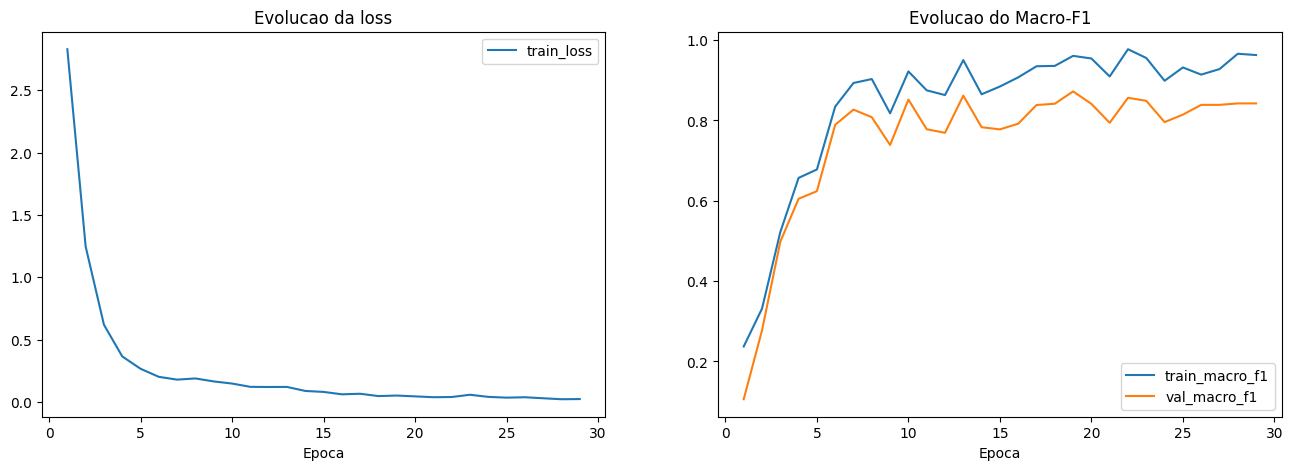

In [9]:
history = pd.read_csv(training_summary.history_path)
display(history.tail())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(history["epoch"], history["train_loss"], label="train_loss")
axes[0].set_title("Evolucao da loss")
axes[0].set_xlabel("Epoca")
axes[0].legend()

axes[1].plot(history["epoch"], history["train_macro_f1"], label="train_macro_f1")
axes[1].plot(history["epoch"], history["val_macro_f1"], label="val_macro_f1")
axes[1].set_title("Evolucao do Macro-F1")
axes[1].set_xlabel("Epoca")
axes[1].legend()
plt.show()

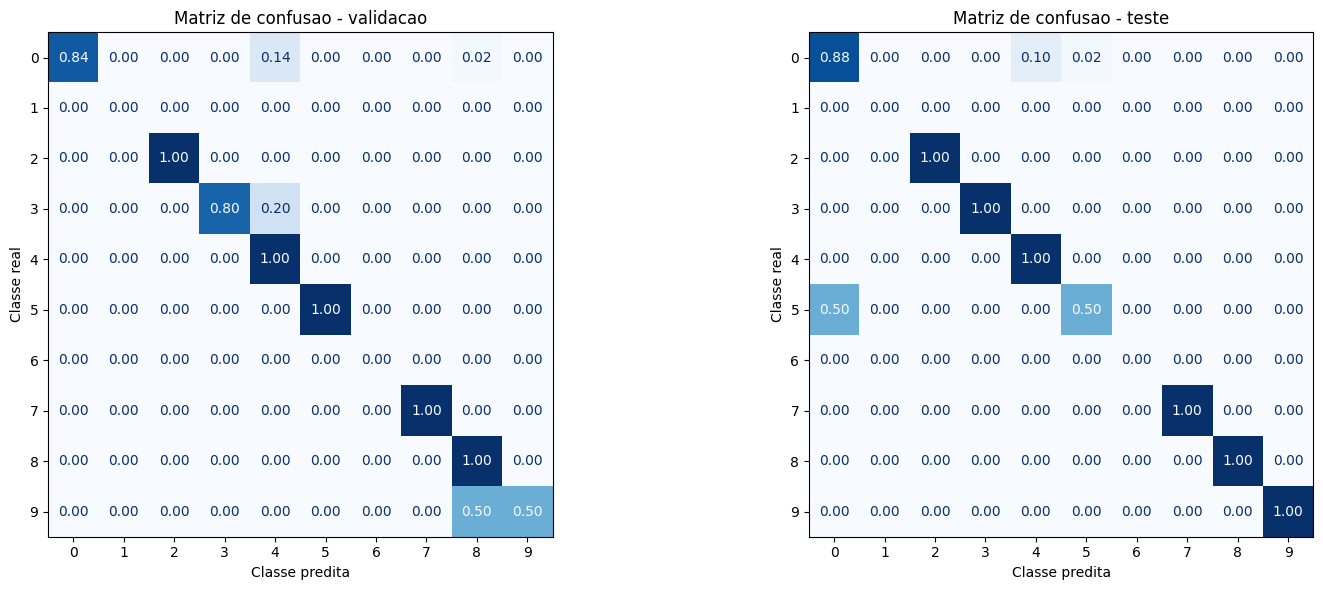

,label,precision,recall,f1-score,support
0,0,0.977778,0.880000,0.926316,50.000000
1,1,0.000000,0.000000,0.000000,0.000000
2,2,1.000000,1.000000,1.000000,1.000000
3,3,1.000000,1.000000,1.000000,5.000000
4,4,0.814815,1.000000,0.897959,22.000000
5,5,0.500000,0.500000,0.500000,2.000000
6,6,0.000000,0.000000,0.000000,0.000000
7,7,1.000000,1.000000,1.000000,5.000000
8,8,1.000000,1.000000,1.000000,2.000000
9,9,1.000000,1.000000,1.000000,2.000000


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_confusion_matrix_for_predictions(
    validation_arrays["y"],
    validation_pred,
    bundle.class_labels,
    normalize="true",
    title="Matriz de confusao - validacao",
    ax=axes[0],
)
plot_confusion_matrix_for_predictions(
    test_arrays["y"],
    test_pred,
    bundle.class_labels,
    normalize="true",
    title="Matriz de confusao - teste",
    ax=axes[1],
)
plt.tight_layout()
plt.show()

display(test_eval["classification_report_df"])